100%|██████████| 9.91M/9.91M [00:01<00:00, 5.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 138kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


Epoch [1/50] D Loss: 0.9416 G Loss: 1.6205
Epoch [2/50] D Loss: 1.1362 G Loss: 0.7275
Epoch [3/50] D Loss: 0.9480 G Loss: 0.9566
Epoch [4/50] D Loss: 0.9978 G Loss: 1.1715
Epoch [5/50] D Loss: 0.9629 G Loss: 0.9099
Epoch [6/50] D Loss: 1.0350 G Loss: 1.0015
Epoch [7/50] D Loss: 0.9808 G Loss: 1.0982
Epoch [8/50] D Loss: 0.9735 G Loss: 1.2394
Epoch [9/50] D Loss: 0.9647 G Loss: 1.4336
Epoch [10/50] D Loss: 1.1146 G Loss: 0.9772
Epoch [11/50] D Loss: 1.0606 G Loss: 1.6199
Epoch [12/50] D Loss: 0.9382 G Loss: 1.5659
Epoch [13/50] D Loss: 0.9888 G Loss: 0.8874
Epoch [14/50] D Loss: 0.8973 G Loss: 0.9197
Epoch [15/50] D Loss: 0.9668 G Loss: 1.1871
Epoch [16/50] D Loss: 0.9301 G Loss: 0.8961
Epoch [17/50] D Loss: 0.9404 G Loss: 0.9998
Epoch [18/50] D Loss: 0.8659 G Loss: 1.4254
Epoch [19/50] D Loss: 0.8702 G Loss: 1.2819
Epoch [20/50] D Loss: 1.0533 G Loss: 0.7853
Epoch [21/50] D Loss: 0.8355 G Loss: 1.4340
Epoch [22/50] D Loss: 1.2387 G Loss: 2.2519
Epoch [23/50] D Loss: 1.2090 G Loss: 1.92

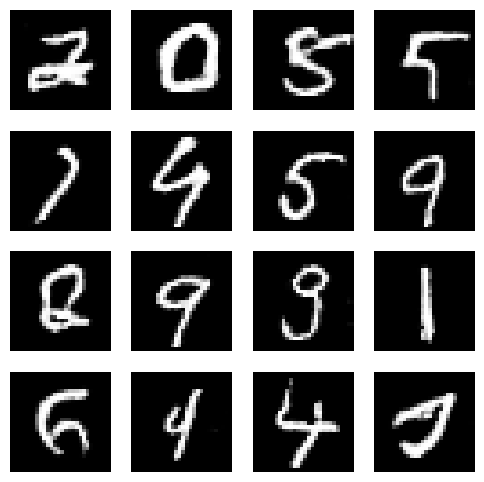

In [1]:
# Exp 5 : DCGAN Network Model for image dataset

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ==============================
# HYPERPARAMETERS
# ==============================
batch_size = 128
image_size = 28
channels = 1
latent_dim = 100
features_g = 64
features_d = 64
epochs = 50
lr = 2e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# DATASET
# ==============================
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# ==============================
# WEIGHT INITIALIZATION
# ==============================
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)

# ==============================
# GENERATOR
# ==============================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, features_g * 4, 7, 1, 0, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 2, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

# ==============================
# DISCRIMINATOR
# ==============================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, features_d, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(features_d, features_d * 2, 4, 2, 1),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2),

            nn.Conv2d(features_d * 2, 1, 7, 1, 0)
            # NO Sigmoid (handled by BCEWithLogitsLoss)
        )

    def forward(self, x):
        return self.net(x).view(x.size(0), -1)

# ==============================
# INITIALIZE MODELS
# ==============================
G = Generator().to(device)
D = Discriminator().to(device)

initialize_weights(G)
initialize_weights(D)

# ==============================
# LOSS & OPTIMIZER
# ==============================
criterion = nn.BCEWithLogitsLoss()

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# ==============================
# TRAINING LOOP
# ==============================
for epoch in range(epochs):
    for real_imgs, _ in loader:
        real_imgs = real_imgs.to(device)
        cur_batch_size = real_imgs.size(0)

        real_labels = torch.ones(cur_batch_size, 1).to(device)
        fake_labels = torch.zeros(cur_batch_size, 1).to(device)

        # ======================
        # TRAIN DISCRIMINATOR
        # ======================
        noise = torch.randn(cur_batch_size, latent_dim, 1, 1).to(device)
        fake_imgs = G(noise)

        real_loss = criterion(D(real_imgs), real_labels)
        fake_loss = criterion(D(fake_imgs.detach()), fake_labels)
        d_loss = real_loss + fake_loss

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # ======================
        # TRAIN GENERATOR
        # ======================
        output = D(fake_imgs)
        g_loss = criterion(output, real_labels)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

# ==============================
# GENERATE SAMPLES
# ==============================
G.eval()
with torch.no_grad():
    noise = torch.randn(16, latent_dim, 1, 1).to(device)
    samples = G(noise).cpu()
    samples = (samples + 1) / 2  # Rescale to [0,1]

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(samples[i][0], cmap="gray")
        ax.axis("off")

    plt.show()